# **Visualisasi Data dengan Matplotlib (CPMK M3)**

Materi Pokok:

1.	Visualisasi dasar: line plot, bar chart, scatter plot, dan histogram

2.	Kustomisasi grafik: judul, label sumbu, legenda

3.	Subplot dan pengaturan tata letak

4.	Visualisasi distribusi dan hubungan antarvariabel

Nama:Rinaldi Hamzah

NIM:5220411342

Program Studi:Informatika

In [1]:
#Mengakses Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel('/content/drive/MyDrive/Semester7 2026/Data Science/pizza_sales_raw.xlsx', header=1)
#semua bentuk karakteristik data bisa di import seperti excel,csv,json
df.head() #melihat 5 baris data pertama

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1.0,1.0,hawaiian_m,1.0,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2.0,2.0,classic_dlx_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3.0,2.0,five_cheese_l,1.0,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4.0,2.0,ital_supr_l,1.0,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5.0,2.0,mexicana_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [6]:
#mengahpus angka nul
df['pizza_id'] = df['pizza_id'].astype(int)
df['order_id'] = df['order_id'].astype(int)
df['quantity'] = df['quantity'].astype(int)
df['total_price'] = df['total_price'].astype(int)
df['unit_price'] = df['unit_price'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   pizza_id           48620 non-null  int64 
 1   order_id           48620 non-null  int64 
 2   pizza_name_id      48620 non-null  object
 3   quantity           48620 non-null  int64 
 4   order_date         48620 non-null  object
 5   order_time         48620 non-null  object
 6   unit_price         48620 non-null  int64 
 7   total_price        48620 non-null  int64 
 8   pizza_size         48620 non-null  object
 9   pizza_category     48620 non-null  object
 10  pizza_ingredients  48620 non-null  object
 11  pizza_name         48620 non-null  object
dtypes: int64(5), object(7)
memory usage: 4.5+ MB


In [11]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# 3.1 Visualisasi dasar: line plot, bar chart, scatter plot, dan histogram

In [12]:
df['order_date'] = pd.to_datetime(df['order_date'])

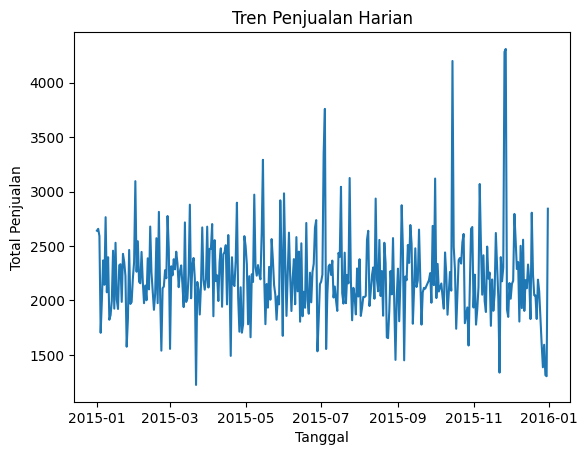

In [13]:
#Line Plot – Tren Penjualan Harian
daily_sales = df.groupby('order_date')['total_price'].sum()
plt.figure()
plt.plot(daily_sales.index, daily_sales.values)
plt.xlabel('Tanggal')
plt.ylabel('Total Penjualan')
plt.title('Tren Penjualan Harian')
plt.show()

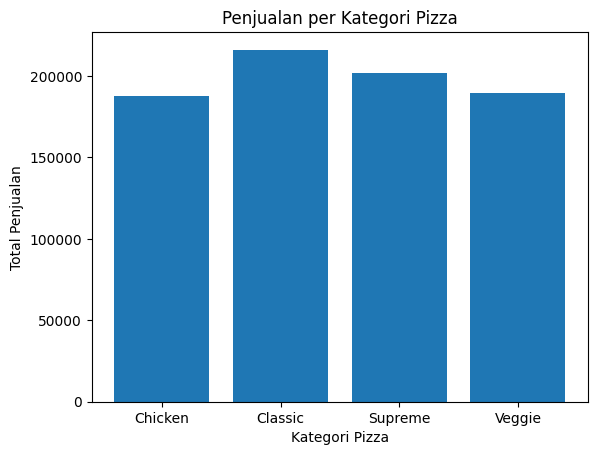

In [14]:
#Bar Chart – Penjualan per Kategori Pizza
category_sales = df.groupby('pizza_category')['total_price'].sum()
plt.figure()
plt.bar(category_sales.index, category_sales.values)
plt.xlabel('Kategori Pizza')
plt.ylabel('Total Penjualan')
plt.title('Penjualan per Kategori Pizza')
plt.show()

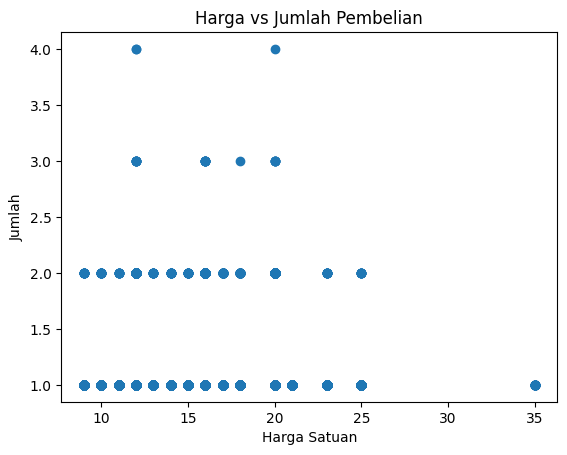

In [15]:
#Scatter Plot – Harga vs Jumlah
plt.figure()
plt.scatter(df['unit_price'], df['quantity'])
plt.xlabel('Harga Satuan')
plt.ylabel('Jumlah')
plt.title('Harga vs Jumlah Pembelian')
plt.show()

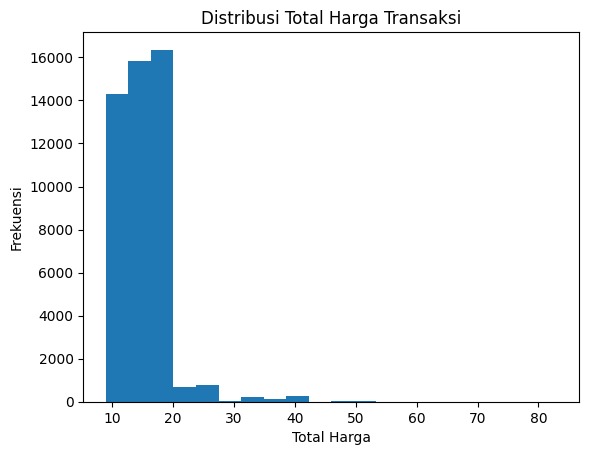

In [16]:
#Histogram – Distribusi Total Transaksi
plt.figure()
plt.hist(df['total_price'], bins=20)
plt.xlabel('Total Harga')
plt.ylabel('Frekuensi')
plt.title('Distribusi Total Harga Transaksi')
plt.show()

# 3.2 Kustomisasi grafik: judul, label sumbu, legenda

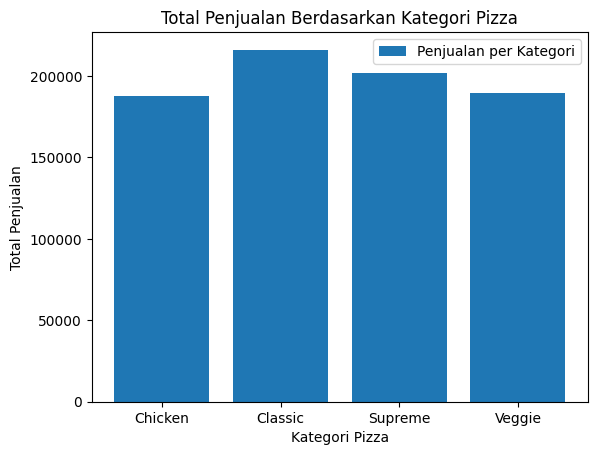

In [17]:
plt.figure()
plt.bar(category_sales.index, category_sales.values, label='Penjualan per Kategori')

plt.title('Total Penjualan Berdasarkan Kategori Pizza')
plt.xlabel('Kategori Pizza')
plt.ylabel('Total Penjualan')
plt.legend()

plt.show()

# 3.3 Subplot dan pengaturan tata letak

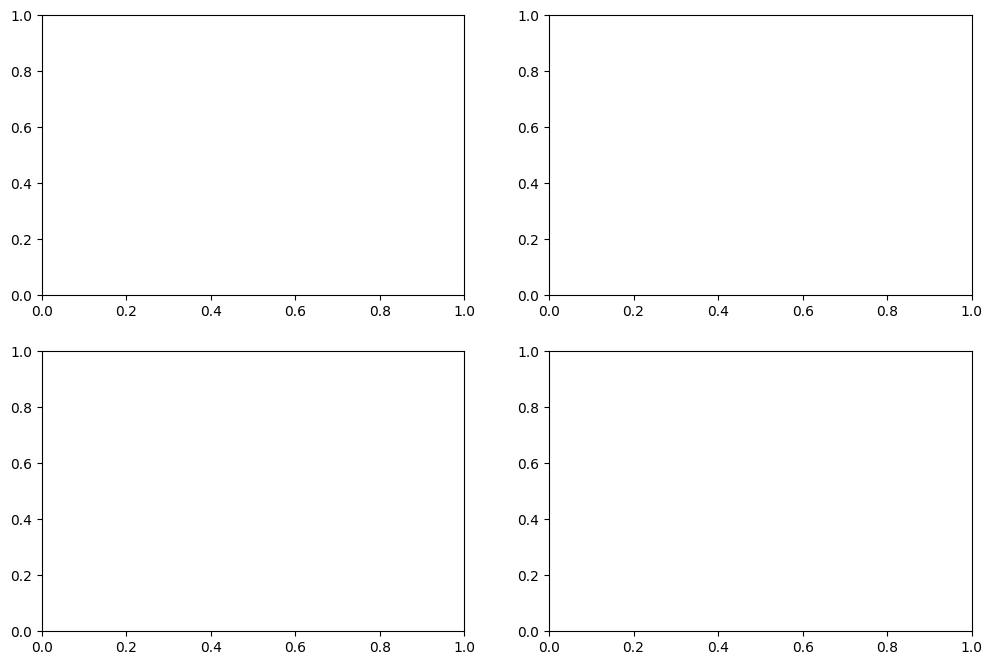

In [20]:
#Subplot memungkinkan beberapa grafik ditampilkan dalam satu figure.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
#fig, axes = plt.subplots(baris, kolom, figsize=(lebar, tinggi))

Text(0.5, 1.0, 'Distribusi Total Harga')

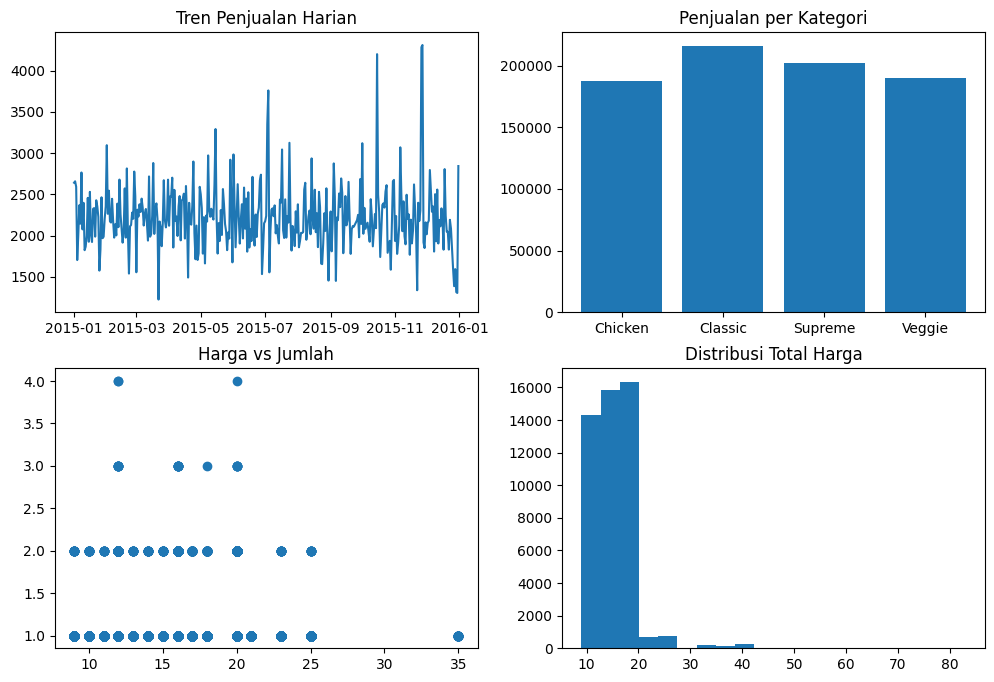

In [21]:
#Contoh Lengkap (Pizza Sales)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Line plot
axes[0, 0].plot(daily_sales.index, daily_sales.values)
axes[0, 0].set_title('Tren Penjualan Harian')

# Bar chart
axes[0, 1].bar(category_sales.index, category_sales.values)
axes[0, 1].set_title('Penjualan per Kategori')

# Scatter plot
axes[1, 0].scatter(df['unit_price'], df['quantity'])
axes[1, 0].set_title('Harga vs Jumlah')

# Histogram
axes[1, 1].hist(df['total_price'], bins=20)
axes[1, 1].set_title('Distribusi Total Harga')

In [22]:
#Pengaturan Tata Letak (Layout)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [23]:
#plt.subplots_adjust() (Kontrol Manual)
plt.subplots_adjust(
    left=0.1,
    right=0.95,
    top=0.9,
    bottom=0.1,
    wspace=0.3,
    hspace=0.4
)

<Figure size 640x480 with 0 Axes>

In [24]:
#Judul Global (suptitle)
fig.suptitle('Analisis Penjualan Pizza', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])

<Figure size 640x480 with 0 Axes>

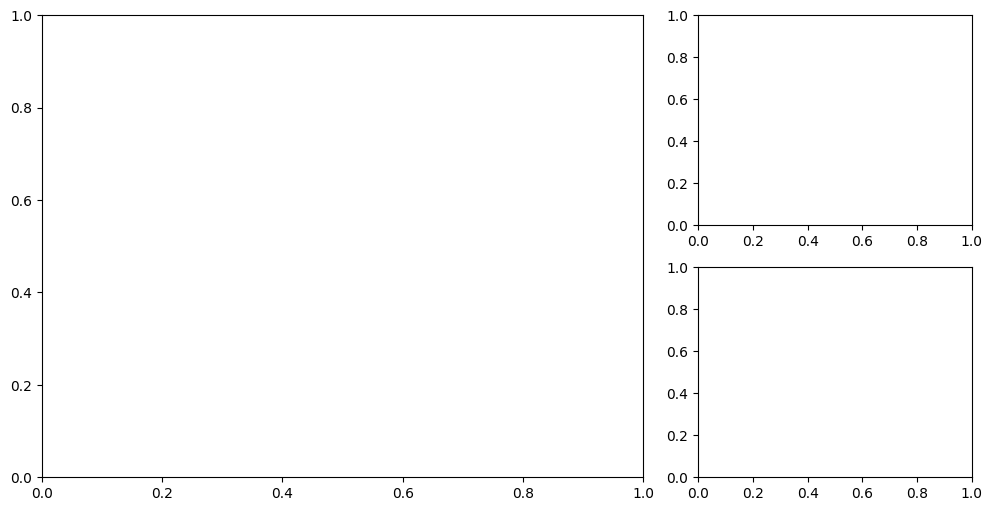

In [25]:
#Layout Tidak Simetris (Advanced)
fig = plt.figure(figsize=(12, 6))

ax1 = plt.subplot2grid((2, 3), (0, 0), colspan=2, rowspan=2)
ax2 = plt.subplot2grid((2, 3), (0, 2))
ax3 = plt.subplot2grid((2, 3), (1, 2))

# 3.4 Visualisasi distribusi dan hubungan antar variabel

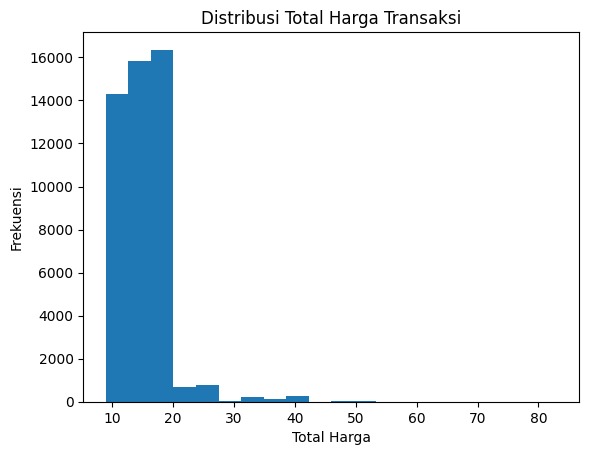

In [28]:
#Histogram – Distribusi total_price
plt.figure()
plt.hist(df['total_price'], bins=20)
plt.title('Distribusi Total Harga Transaksi')
plt.xlabel('Total Harga')
plt.ylabel('Frekuensi')
plt.show()

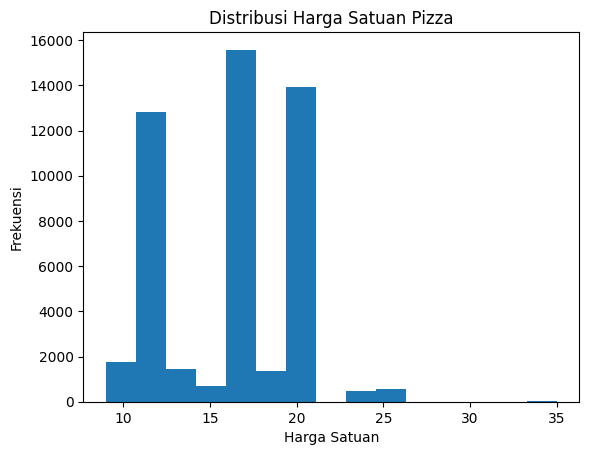

In [29]:
#Histogram – Distribusi unit_price
plt.figure()
plt.hist(df['unit_price'], bins=15)
plt.title('Distribusi Harga Satuan Pizza')
plt.xlabel('Harga Satuan')
plt.ylabel('Frekuensi')
plt.show()

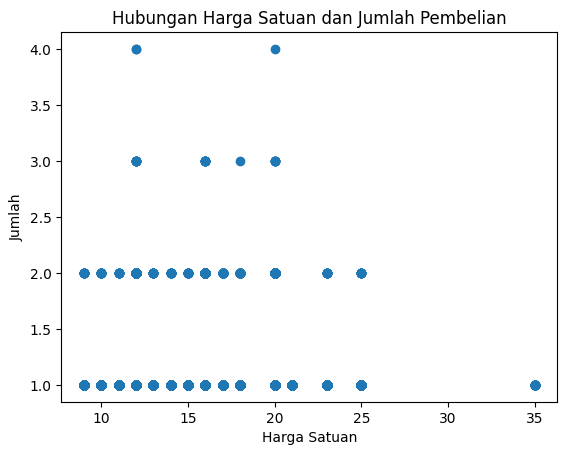

In [30]:
#Visualisasi Hubungan Antar Variabel
#Scatter Plot – Harga vs Jumlah
plt.figure()
plt.scatter(df['unit_price'], df['quantity'])
plt.title('Hubungan Harga Satuan dan Jumlah Pembelian')
plt.xlabel('Harga Satuan')
plt.ylabel('Jumlah')
plt.show()

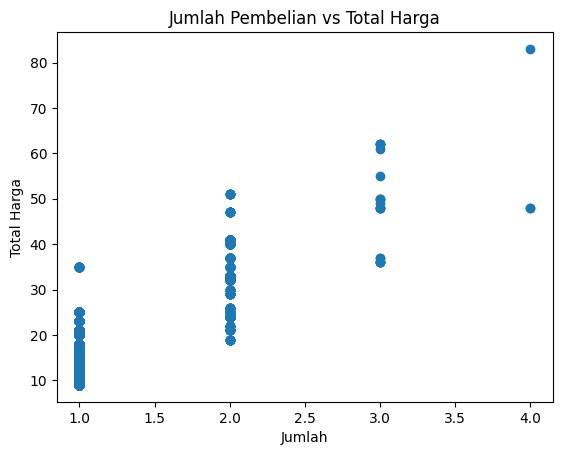

In [31]:
#Scatter Plot – Quantity vs Total Price
plt.figure()
plt.scatter(df['quantity'], df['total_price'])
plt.title('Jumlah Pembelian vs Total Harga')
plt.xlabel('Jumlah')
plt.ylabel('Total Harga')
plt.show()

/tmp/ipython-input-4279162451.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


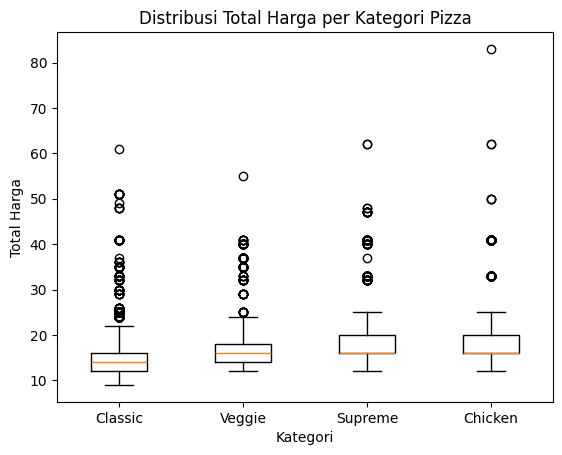

In [32]:
#Distribusi Berdasarkan Kategori (Opsional tapi Kuat)
#Boxplot – Total Price per Kategori
plt.figure()
plt.boxplot(
    [df[df['pizza_category'] == cat]['total_price']
     for cat in df['pizza_category'].unique()],
    labels=df['pizza_category'].unique()
)

plt.title('Distribusi Total Harga per Kategori Pizza')
plt.xlabel('Kategori')
plt.ylabel('Total Harga')
plt.show()

# Tugas Praktikum:

1.	Buat histogram distribusi jumlah pendapatan berdasarkan bulan.

In [34]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Hapus tanggal tidak valid
df = df.dropna(subset=['order_date'])

# Ekstrak bulan
df['month'] = df['order_date'].dt.month

In [35]:
monthly_revenue = (
    df.groupby('month')['total_price']
      .sum()
)

In [37]:
monthly_revenue.index = monthly_revenue.index.map({
    1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',
    7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'
})


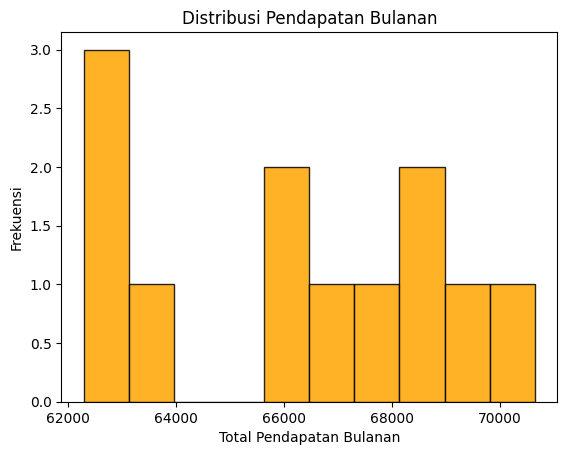

In [39]:
plt.figure()
plt.hist(
    monthly_revenue.values,
    bins=10,
    color='orange',
    edgecolor='black',
    alpha=0.85
)

plt.title('Distribusi Pendapatan Bulanan')
plt.xlabel('Total Pendapatan Bulanan')
plt.ylabel('Frekuensi')

plt.show()

2.	Buat scatter plot untuk menganalisis hubungan antara jumlah total penjualan dan kategory pizza.

In [40]:
#agregasi data
# Ambil kategori unik
categories = df['pizza_category'].unique()

# Peta kategori ke angka
category_map = {cat: i for i, cat in enumerate(categories)}
df['category_num'] = df['pizza_category'].map(category_map)

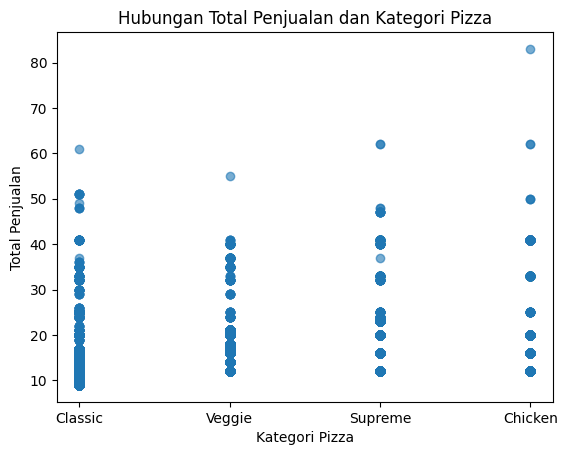

In [41]:
plt.figure()
plt.scatter(
    df['category_num'],
    df['total_price'],
    alpha=0.6
)

plt.title('Hubungan Total Penjualan dan Kategori Pizza')
plt.xlabel('Kategori Pizza')
plt.ylabel('Total Penjualan')

# Label kategori di sumbu X
plt.xticks(
    ticks=range(len(categories)),
    labels=categories
)

plt.show()

**Kesimpulan**

Visualisasi menunjukkan bahwa fokus strategi bisnis sebaiknya pada kategori terlaris,
optimasi waktu penjualan, dan peningkatan nilai transaksi, bukan hanya penyesuaian harga.